# ETC filter curve demo with Spextra and Synphot

Use case for each library:
- Spextra has a set of filters and source spectra built in and you can import your own
- Synphot is lower level and probably more reliable in terms of long term support
- Probably, use Spextra to manage filters/specta and Synphot for calculations and more customization

Spextra is built on top of Synphot so they work well together:
- For example, a Spextra Spextrum can be passed as a spectrum to Syphot's observation class

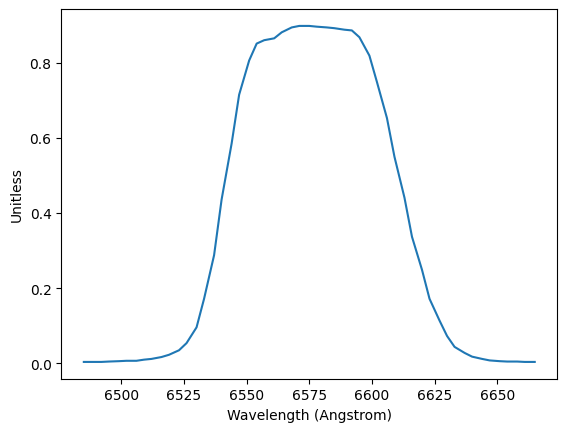

In [97]:
# simple spextra filter import - https://spextra.readthedocs.io/stable/filters.html
from spextra import Passband

ha = Passband("HAlpha")
ha.plot()

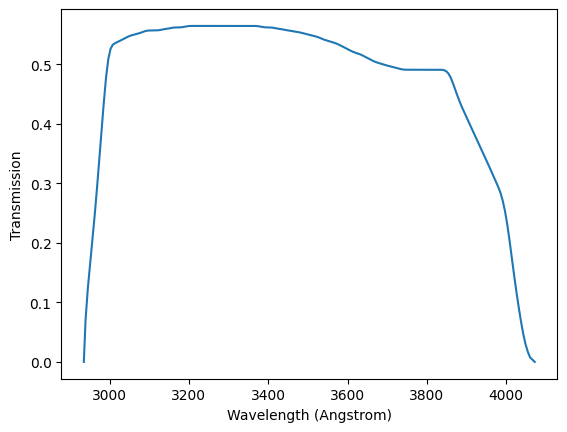

In [98]:
# custom CASTOR filter import from file using Spexctra or Synphot
import matplotlib.pyplot as plt

# filter source - http://svo2.cab.inta-csic.es/theory/fps/index.php?id=CASTOR/CASTOR0.u&&mode=browse&gname=CASTOR&gname2=CASTOR0#filter
from spextra import Passband
castor_filter = Passband.from_file("CASTOR_CASTOR0.u.dat")

# you can do the exact same thing with Synphot:
from synphot import SpectralElement
castor_filter = SpectralElement.from_file("CASTOR_CASTOR0.u.dat")

# values for plotting
waves = castor_filter.waveset
transmission = castor_filter(waves)

plt.plot(waves, transmission)
plt.xlabel(f"Wavelength ({waves.unit})")
plt.ylabel("Transmission")
plt.show()

        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


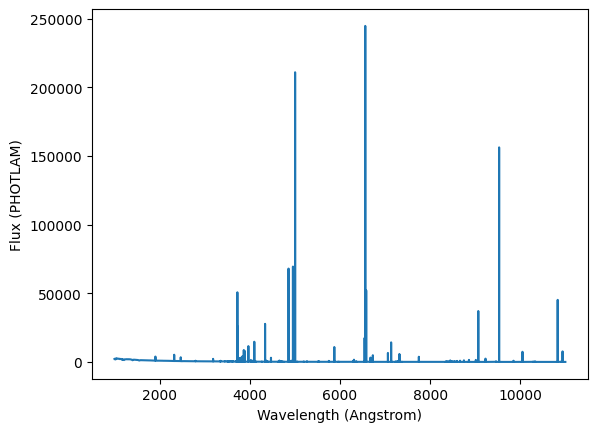

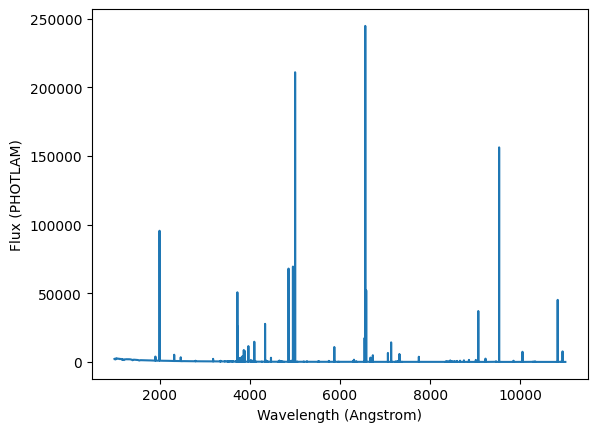

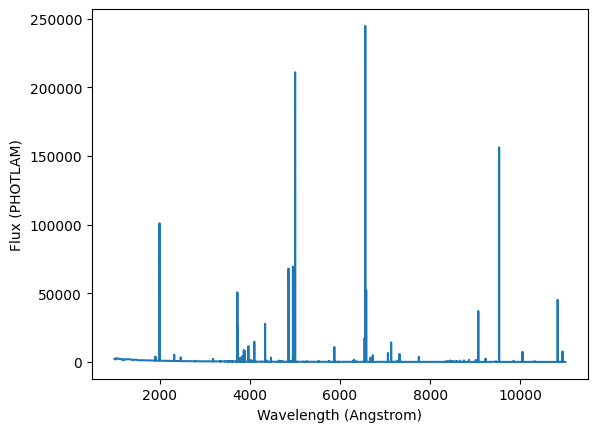

In [105]:
# Spextra default emission line nebulae (only orion is available so not very useful)
from spextra import Spextrum
orion = Spextrum("nebulae/orion")
orion.plot()

# add an emission line - this is pretty much straight from the Spextra docs (second plot)
from astropy import units as u
sp3 = orion.add_emi_lines(center=2000,flux=5e-6, fwhm=5*u.AA)
sp3.plot()

# you can also just add a gaussian to the current spectrum (third plot)
from synphot import SourceSpectrum
from synphot.models import GaussianFlux1D

line = SourceSpectrum(GaussianFlux1D, amplitude=100000, mean=2000*u.AA,fwhm=5 * u.AA)
addition = orion + line
addition.plot()


In [100]:
# you can import your own spectrum (download elsewhere) like this - commented out to prevent errors

# Spextra custom import
# from spextra import Spextrum
# crab = Spextrum.from_file("filename.fits")

# Synphot custom import (basically the same again)
# from synphot import SourceSpectrum
# crab = SourceSpectrum.from_file("filename.fits")

In [101]:
# flux integration - ETC approach (current method)
'''
Note: this approach shows scaling the spectrum using AB mag
'''
from spextra import Spextrum
import astropy.units as u

demo_mag = 10   # this is the magnitude of the object through a specific filter, say "R" as below
demo_mirror_area = 1000  # cm2

star_spec = Spextrum("pickles/g0v").scale_to_magnitude(amplitude=demo_mag*u.ABmag, filter_curve="R") # make sure the magnitude system matches the units (AB vs Vega)
star_photons = star_spec.photons_in_range(area=demo_mirror_area,filter_curve="CASTOR_CASTOR0.u.dat")
print(star_photons)

        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


16183.285997479623 ct / s


In [102]:
# flux integration - SNR approach
'''
Note: this approach shows scaling the spectrum using Vega mag
'''
from spextra import Spextrum
from synphot import Observation, SourceSpectrum
from synphot import units as su

# fetch a preset spectrum
spectrum = Spextrum(f"pickles/g0v")     # side note: you should be able to add your own emission lines it's in the Spextra docs

# this is left over from the SNR project - see the GitHub if you're interested (calibration_catalogue.ipynb)
vega = SourceSpectrum.from_vega()
demo_mag = 10
scaled_spectum = spectrum.normalize(demo_mag * su.VEGAMAG, band=castor_filter, vegaspec=vega)
      
# calculate the photon flux
obs = Observation(scaled_spectum, castor_filter)
flux = obs.integrate(flux_unit=su.PHOTLAM)  # you can change this to FLAM for erg/s/cm2
print(flux)

37.93299343177527 ph / (s cm2)


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


In [103]:
# quick comparison between both approaches - results are practically identical

# Spextra method (same as above)
star_spec = Spextrum("pickles/g0v").scale_to_magnitude(amplitude=10 * u.ABmag, filter_curve="R")
spextra_cts = star_spec.photons_in_range(area=1000, filter_curve="CASTOR_CASTOR0.u.dat")

# Synphot method - similar to above just using the same filter and magnitude
r_band = Passband("R")
castor_filter = Passband.from_file("CASTOR_CASTOR0.u.dat")
scaled_spec = Spextrum("pickles/g0v").normalize(10 * u.ABmag, band=r_band)

obs = Observation(scaled_spec, castor_filter)
photon_flux = obs.integrate(flux_unit=su.PHOTLAM)
synphot_cts = photon_flux * (1000 * u.cm**2)    # this is just the ph/s/cm2 multiplied by the same mirror area

# results
print("Spextra:", spextra_cts)
print("Synphot:", synphot_cts)


Spextra: 16183.285997479623 ct / s
Synphot: 16183.063021764809 ph / s


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


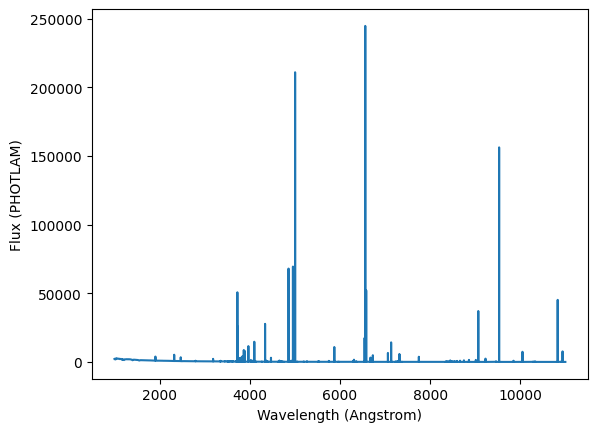

In [104]:
from spextra import Spextrum

spectrum = Spextrum.from_file(
    "CASTOR_CASTOR0.u.dat",
    wave_unit="angstrom",
    flux_unit="flam"
)

# spectrum.plot()


spec = Spextrum("nebulae/orion")
spec.plot()